In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [16]:
df = pd.read_csv('features_engineered.csv')
print(f"Loaded {len(df)} games with {len(df.columns)} features\n")

Loaded 65579 games with 96 features



In [17]:
# Define recommended features based on correlation analysis
recommended_features = [
    'elo_diff', 'home_elo_before', 'away_elo_before',
    
    'win_rate_diff_L20', 'win_rate_diff_L10', 'win_rate_diff_L5',
    'home_win_rate_L20', 'home_win_rate_L10', 'home_win_rate_L5',
    'away_win_rate_L20', 'away_win_rate_L10', 'away_win_rate_L5',
    
    'fg_pct_diff_L20', 'fg_pct_diff_L10', 'fg_pct_diff_L5',
    'fg3_pct_diff_L20', 'fg3_pct_diff_L10', 'fg3_pct_diff_L5',
    
    'h2h_home_win_rate', 'h2h_total_games',
    
    'is_home', 'season_progress',
]

available_features = [f for f in recommended_features if f in df.columns]

In [18]:
# Prepare X and y
X = df[available_features].copy()
y = df['home_win'].copy()

# Remove rows with missing values
mask = ~(X.isna().any(axis=1) | y.isna())
X = X[mask]
y = y[mask]

print(f"After removing missing values: {len(X)} games")
print(f"Target distribution: {y.value_counts().to_dict()}")
print(f"Home win rate: {y.mean():.3f}\n")

After removing missing values: 46812 games
Target distribution: {1: 28279, 0: 18533}
Home win rate: 0.604



In [19]:
# Split data chronologically (important for time series)
# Use 80% for training, 20% for testing
split_idx = int(len(X) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Training set: {len(X_train)} games")
print(f"Test set: {len(X_test)} games")
print(f"Train home win rate: {y_train.mean():.3f}")
print(f"Test home win rate: {y_test.mean():.3f}\n")

Training set: 37449 games
Test set: 9363 games
Train home win rate: 0.613
Test home win rate: 0.569



In [20]:
# Scale features
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling complete\n")

Scaling features...
Feature scaling complete



## Baseline Model: Always Predict Home Win

In [22]:
print("=" * 80)
print("BASELINE MODEL: Always Predict Home Win")
print("=" * 80)
print()

# Predict all home wins
y_pred_baseline = np.ones(len(y_test))
y_pred_proba_baseline = np.ones(len(y_test))

# Calculate metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_roc_auc = roc_auc_score(y_test, y_pred_proba_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"ROC AUC:   {baseline_roc_auc:.4f}")
print(f"F1 Score:  {baseline_f1:.4f}")
print()

# Store results
results = {
    'Baseline': {
        'accuracy': baseline_accuracy,
        'roc_auc': baseline_roc_auc,
        'f1': baseline_f1,
        'y_pred': y_pred_baseline,
        'y_pred_proba': y_pred_proba_baseline
    }
}

BASELINE MODEL: Always Predict Home Win

Accuracy:  0.5692
ROC AUC:   0.5000
F1 Score:  0.7254



## Logistic Regression

In [23]:
print("=" * 80)
print("MODEL 1: Logistic Regression")
print("=" * 80)
print()

print("Training Logistic Regression with L2 regularization...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,  # Regularization strength
    solver='lbfgs'
)

lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_pred_proba_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

results['Logistic Regression'] = {
    'accuracy': lr_accuracy,
    'roc_auc': lr_roc_auc,
    'f1': lr_f1,
    'y_pred': y_pred_lr,
    'y_pred_proba': y_pred_proba_lr,
    'model': lr_model
}

print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"ROC AUC:   {lr_roc_auc:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")
print()

# Feature importance
feature_importance_lr = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("Top 10 Most Important Features:")
for idx, row in feature_importance_lr.head(10).iterrows():
    print(f"  {row['feature']:30s} | Coef: {row['coefficient']:7.4f}")
print()

MODEL 1: Logistic Regression

Training Logistic Regression with L2 regularization...
Accuracy:  0.6410
ROC AUC:   0.6785
F1 Score:  0.7228

Top 10 Most Important Features:
  elo_diff                       | Coef:  0.3641
  away_elo_before                | Coef: -0.2610
  home_elo_before                | Coef:  0.2467
  win_rate_diff_L20              | Coef:  0.0642
  away_win_rate_L10              | Coef:  0.0581
  away_win_rate_L20              | Coef: -0.0550
  home_win_rate_L10              | Coef:  0.0418
  fg_pct_diff_L5                 | Coef:  0.0409
  fg3_pct_diff_L10               | Coef:  0.0381
  fg3_pct_diff_L5                | Coef: -0.0360



## Model Comparison

In [24]:
print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print()

# Create comparison DataFrame
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'ROC AUC': [results[m]['roc_auc'] for m in results.keys()],
    'F1 Score': [results[m]['f1'] for m in results.keys()]
})

print(comparison.to_string(index=False))
print()

# Find best model
best_model_name = comparison.loc[comparison['Accuracy'].idxmax(), 'Model']
print(f"Best Model by Accuracy: {best_model_name}")
print(f"  Accuracy:  {comparison.loc[comparison['Accuracy'].idxmax(), 'Accuracy']:.4f}")
print(f"  ROC AUC:   {comparison.loc[comparison['Accuracy'].idxmax(), 'ROC AUC']:.4f}")
print(f"  F1 Score:  {comparison.loc[comparison['Accuracy'].idxmax(), 'F1 Score']:.4f}")
print()

# Save comparison
comparison.to_csv('model_comparison.csv', index=False)
print("Model comparison saved to: model_comparison.csv\n")

MODEL COMPARISON

              Model  Accuracy  ROC AUC  F1 Score
           Baseline  0.569155 0.500000  0.725429
Logistic Regression  0.641034 0.678488  0.722804

Best Model by Accuracy: Logistic Regression
  Accuracy:  0.6410
  ROC AUC:   0.6785
  F1 Score:  0.7228

Model comparison saved to: model_comparison.csv



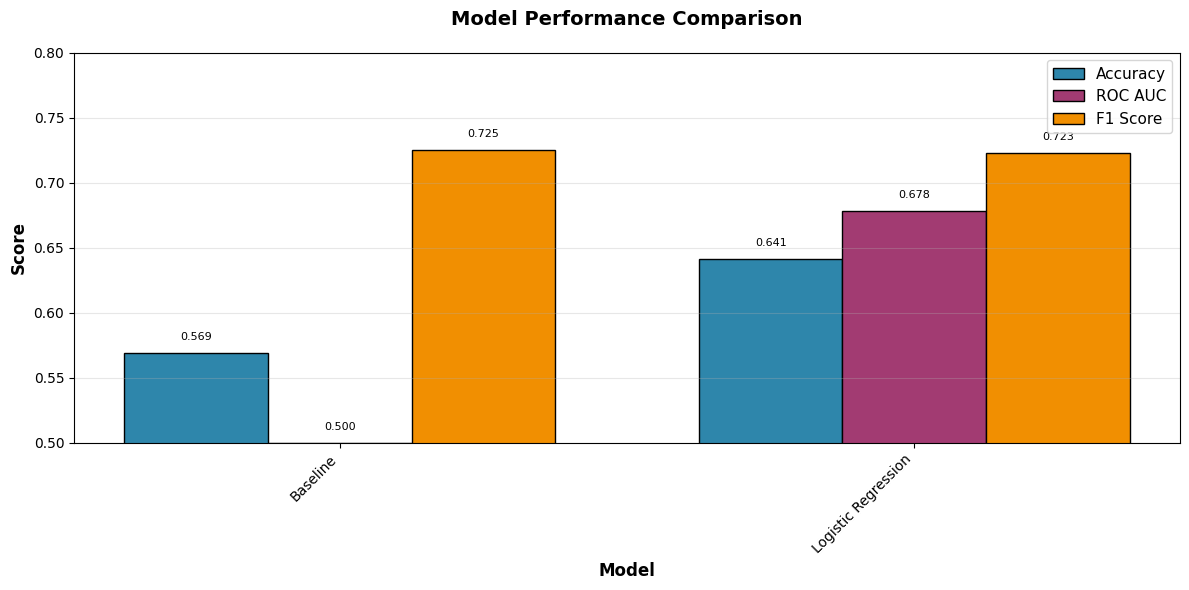

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison))
width = 0.25

ax.bar(x - width, comparison['Accuracy'], width, label='Accuracy', color='#2E86AB', edgecolor='black')
ax.bar(x, comparison['ROC AUC'], width, label='ROC AUC', color='#A23B72', edgecolor='black')
ax.bar(x + width, comparison['F1 Score'], width, label='F1 Score', color='#F18F01', edgecolor='black')

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'], rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0.5, 0.8])

# Add value labels
for i, model in enumerate(comparison['Model']):
    ax.text(i - width, comparison.loc[i, 'Accuracy'] + 0.01, 
            f"{comparison.loc[i, 'Accuracy']:.3f}", ha='center', fontsize=8)
    ax.text(i, comparison.loc[i, 'ROC AUC'] + 0.01, 
            f"{comparison.loc[i, 'ROC AUC']:.3f}", ha='center', fontsize=8)
    ax.text(i + width, comparison.loc[i, 'F1 Score'] + 0.01, 
            f"{comparison.loc[i, 'F1 Score']:.3f}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

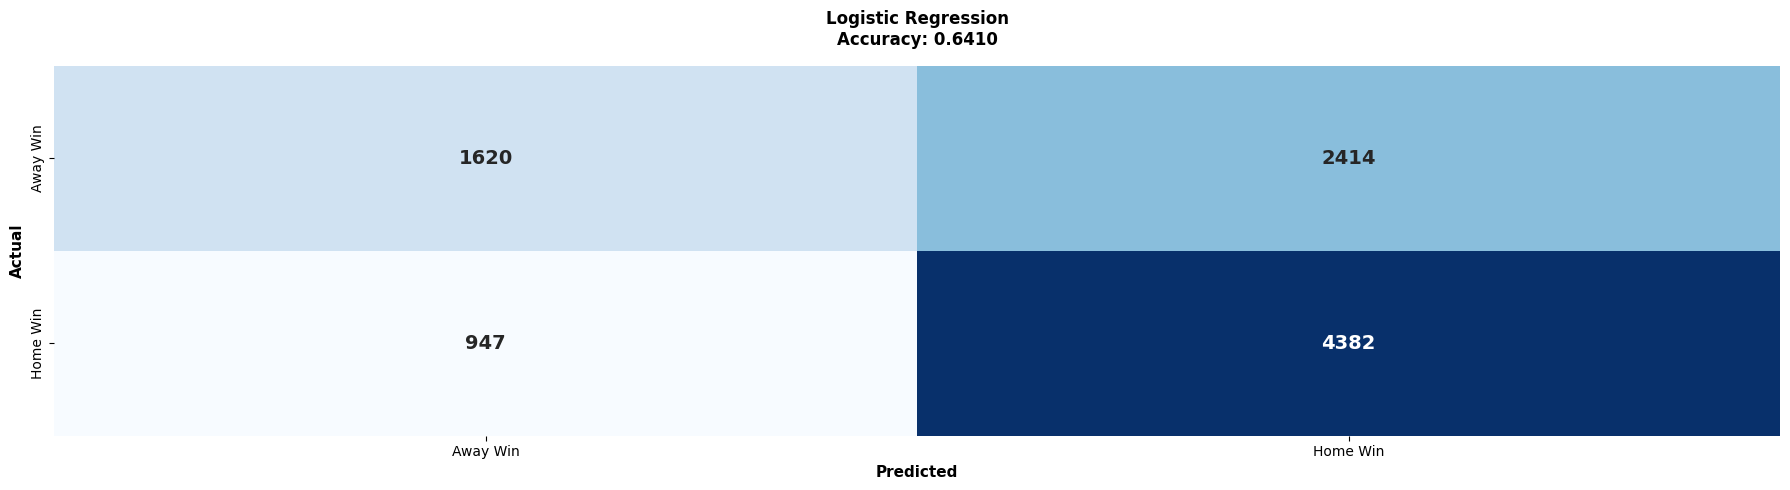

In [26]:
model_names = ['Logistic Regression' ]

fig, axes = plt.subplots(1, len(model_names), figsize=(18, 5))


for idx, model_name in enumerate(model_names):
    ax = axes[idx] if axes is list else axes
    cm = confusion_matrix(y_test, results[model_name]['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
    ax.set_title(f'{model_name}\nAccuracy: {results[model_name]["accuracy"]:.4f}', 
                 fontsize=12, fontweight='bold', pad=15)
    ax.set_xticklabels(['Away Win', 'Home Win'])
    ax.set_yticklabels(['Away Win', 'Home Win'])

plt.tight_layout()
plt.show()

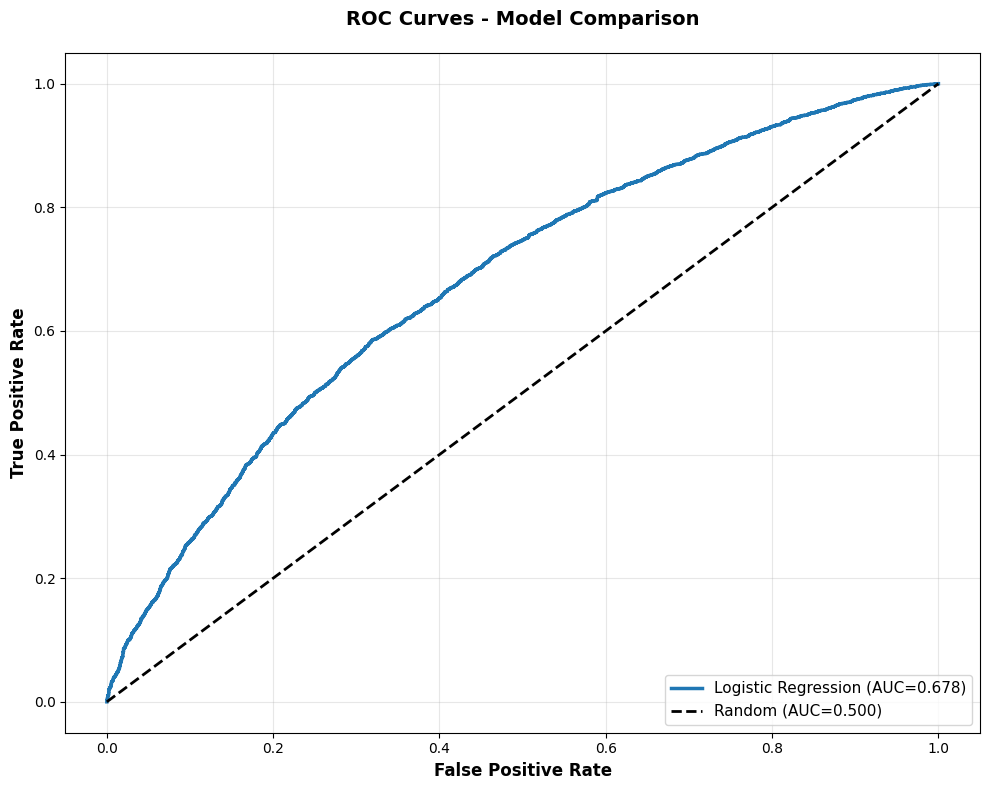

In [27]:
plt.figure(figsize=(10, 8))

for model_name in model_names:
    fpr, tpr, _ = roc_curve(y_test, results[model_name]['y_pred_proba'])
    auc = results[model_name]['roc_auc']
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})', linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold', pad=20)
plt.legend(fontsize=11, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

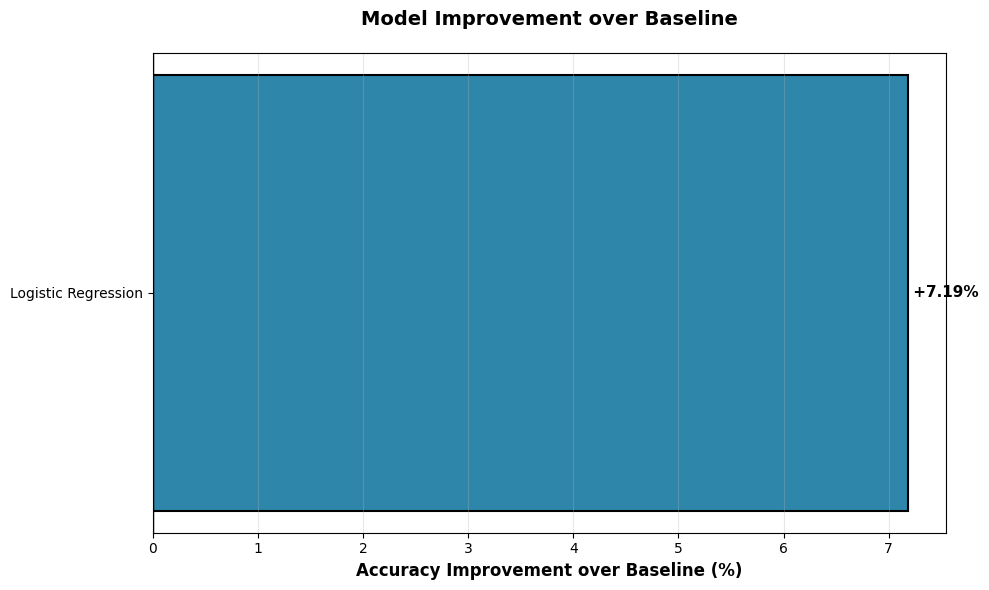


Baseline Accuracy: 0.5692
Logistic Regression: +7.19% improvement


In [28]:
baseline_acc = results['Baseline']['accuracy']
improvements = {
    model: (results[model]['accuracy'] - baseline_acc) * 100
    for model in results.keys() if model != 'Baseline'
}

plt.figure(figsize=(10, 6))
colors = ['#2E86AB' if v > 0 else '#A23B72' for v in improvements.values()]
bars = plt.barh(list(improvements.keys()), list(improvements.values()), 
                color=colors, edgecolor='black', linewidth=1.5)

plt.xlabel('Accuracy Improvement over Baseline (%)', fontsize=12, fontweight='bold')
plt.title('Model Improvement over Baseline', fontsize=14, fontweight='bold', pad=20)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='x', alpha=0.3)

# Add value labels
for bar, value in zip(bars, improvements.values()):
    plt.text(value, bar.get_y() + bar.get_height()/2, 
             f' {value:+.2f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nBaseline Accuracy: {baseline_acc:.4f}")
for model, improvement in improvements.items():
    print(f"{model}: {improvement:+.2f}% improvement")

## Summary and Conclusions

In [29]:
print("=" * 80)
print("TRAINING PIPELINE COMPLETE")
print("=" * 80)
print()

print("📊 Summary:")
print(f"  • Dataset: {len(X)} games")
print(f"  • Features used: {len(available_features)}")
print(f"  • Training set: {len(X_train)} games")
print(f"  • Test set: {len(X_test)} games")
print()

print("🏆 Best Model:")
best_idx = comparison['Accuracy'].idxmax()
print(f"  • Model: {comparison.loc[best_idx, 'Model']}")
print(f"  • Accuracy: {comparison.loc[best_idx, 'Accuracy']:.4f}")
print(f"  • ROC AUC: {comparison.loc[best_idx, 'ROC AUC']:.4f}")
print(f"  • F1 Score: {comparison.loc[best_idx, 'F1 Score']:.4f}")
print()

print("📈 Improvement over Baseline:")
for model in model_names:
    improvement = (results[model]['accuracy'] - baseline_accuracy) * 100
    print(f"  • {model}: {improvement:+.2f}%")
print()

print("✅ All models trained and evaluated successfully!")

TRAINING PIPELINE COMPLETE

📊 Summary:
  • Dataset: 46812 games
  • Features used: 21
  • Training set: 37449 games
  • Test set: 9363 games

🏆 Best Model:
  • Model: Logistic Regression
  • Accuracy: 0.6410
  • ROC AUC: 0.6785
  • F1 Score: 0.7228

📈 Improvement over Baseline:
  • Logistic Regression: +7.19%

✅ All models trained and evaluated successfully!
